In [1]:
import itertools
from physiomodeler import Model

In [2]:
from modellen.luchtstromingen import (
    luchtstromingen_model,
    dynamische_elastantie_drukken_model,
)
from modellen.gasstromingen import gasstromingen_model
from modellen.perfusie import perfusie_model
from modellen.flux import flux_alveoli_PC_model


In [3]:
systeem_model = Model(
    dynamics=[
        dynamische_elastantie_drukken_model,
        flux_alveoli_PC_model,
        luchtstromingen_model,
        gasstromingen_model,
        perfusie_model,
    ],
)

In [4]:
result = systeem_model.run_simulation(
    time=60,
    initial_state={
        "volume_luchtwegen": 0.7,
        "volume_alveoli": 2.8,
        "inhoud_O2_PC": 0.15,  # ±saturatie van 75%
        "inhoud_O2_SA": 0.15,
        "inhoud_O2_SC": 0.15,
        "inhoud_O2_SV": 0.15,
    },
)

array([<Axes: xlabel='time'>, <Axes: xlabel='time'>,
       <Axes: xlabel='time'>, <Axes: xlabel='time'>], dtype=object)

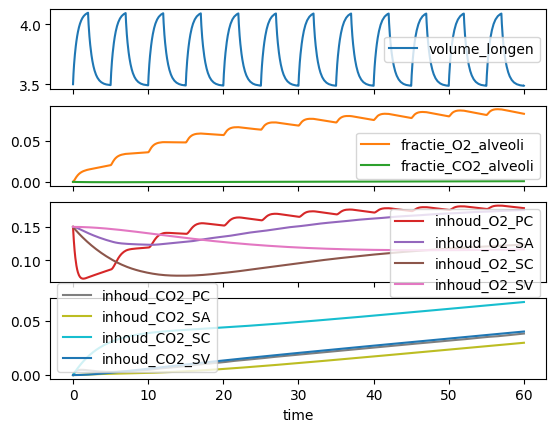

In [5]:
columns = [
    ["volume_longen"],
    ["fractie_O2_alveoli", "fractie_CO2_alveoli"],
    [
        "inhoud_O2_PC",
        "inhoud_O2_SA",
        "inhoud_O2_SC",
        "inhoud_O2_SV",
    ],
    [
        "inhoud_CO2_PC",
        "inhoud_CO2_SA",
        "inhoud_CO2_SC",
        "inhoud_CO2_SV",
    ],
]
result[[*itertools.chain(*columns)]].plot(subplots=columns)

In [6]:
print(systeem_model.state_components)


['volume_luchtwegen', 'volume_alveoli', 'fractie_O2_luchtwegen', 'fractie_O2_alveoli', 'fractie_CO2_luchtwegen', 'fractie_CO2_alveoli', 'inhoud_O2_PC', 'inhoud_O2_SA', 'inhoud_O2_SC', 'inhoud_O2_SV', 'inhoud_CO2_PC', 'inhoud_CO2_SA', 'inhoud_CO2_SC', 'inhoud_CO2_SV']


In [8]:
duur_ademteug = (
    60
    / luchtstromingen_model.inputs["ademhalingsfrequentie"]
)
equilibrium_state = systeem_model.find_equilibrium_state(
    period=duur_ademteug,
    estimated_equilibrium_state={
        "volume_luchtwegen": 0.7,
        "volume_alveoli": 2.8,
        "fractie_O2_luchtwegen": 0.15,
        "fractie_O2_alveoli": 0.12,
        "fractie_CO2_luchtwegen": 0.04,
        "fractie_CO2_alveoli": 0.06,
        "inhoud_O2_PC": 0.19,
        "inhoud_O2_SA": 0.19,
        "inhoud_O2_SC": 0.15,
        "inhoud_O2_SV": 0.15,
        "inhoud_CO2_PC": 0.5,
        "inhoud_CO2_SA": 0.5,
        "inhoud_CO2_SC": 0.55,
        "inhoud_CO2_SV": 0.55,
    },
    relative_tolerance_simulation=1e-3,
    relative_tolerance_equilibrium=1e-2,
)

In [9]:
equilibrium_state

{'volume_luchtwegen': 0.6993728209347437,
 'volume_alveoli': 2.7915495749189687,
 'fractie_O2_luchtwegen': 0.1496695948826688,
 'fractie_O2_alveoli': 0.12069514601052317,
 'fractie_CO2_luchtwegen': 0.03765625811327151,
 'fractie_CO2_alveoli': 0.06053165899400671,
 'inhoud_O2_PC': 0.1951548080395578,
 'inhoud_O2_SA': 0.19379800301643374,
 'inhoud_O2_SC': 0.14332444203863437,
 'inhoud_O2_SV': 0.14811759206387698,
 'inhoud_CO2_PC': 0.5149480629630114,
 'inhoud_CO2_SA': 0.5065076489943935,
 'inhoud_CO2_SC': 0.545280612718844,
 'inhoud_CO2_SV': 0.5483734603269054}

In [9]:
precise_equilibrium_state = systeem_model.find_equilibrium_state(
    period=duur_ademteug,
    estimated_equilibrium_state=equilibrium_state,
    relative_tolerance_simulation=1e-4,  # 10x zo nauwkeurig
    relative_tolerance_equilibrium=1e-3,  # 10x zo nauwkeurig
)

In [10]:
result = systeem_model.run_simulation(
    time=30,
    initial_state=precise_equilibrium_state,
)

array([<Axes: xlabel='time'>, <Axes: xlabel='time'>,
       <Axes: xlabel='time'>], dtype=object)

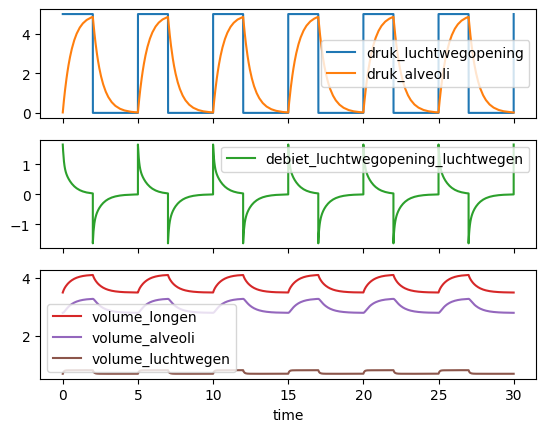

In [11]:
columns = [
    ["druk_luchtwegopening", "druk_alveoli"],
    ["debiet_luchtwegopening_luchtwegen"],
    [
        "volume_longen",
        "volume_alveoli",
        "volume_luchtwegen",
    ],
]
result[list(itertools.chain(*columns))].plot(
    subplots=columns
)

<Axes: xlabel='time'>

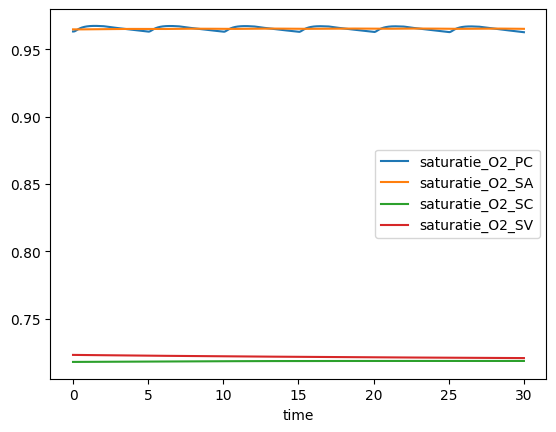

In [12]:
result[
    [
        "saturatie_O2_PC",
        "saturatie_O2_SA",
        "saturatie_O2_SC",
        "saturatie_O2_SV",
    ]
].plot()

array([<Axes: xlabel='time'>, <Axes: xlabel='time'>], dtype=object)

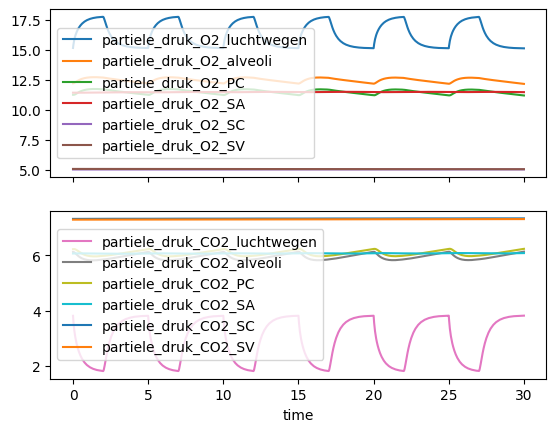

In [13]:
columns_partial_pressures = [
    [
        "partiele_druk_O2_luchtwegen",
        "partiele_druk_O2_alveoli",
        "partiele_druk_O2_PC",
        "partiele_druk_O2_SA",
        "partiele_druk_O2_SC",
        "partiele_druk_O2_SV",
    ],
    [
        "partiele_druk_CO2_luchtwegen",
        "partiele_druk_CO2_alveoli",
        "partiele_druk_CO2_PC",
        "partiele_druk_CO2_SA",
        "partiele_druk_CO2_SC",
        "partiele_druk_CO2_SV",
    ],
]
result[
    list(itertools.chain(*columns_partial_pressures))
].plot(subplots=columns_partial_pressures)


In [14]:
result = systeem_model.run_simulation(
    time=600,
    initial_state=precise_equilibrium_state,
    inputs={
        "flux_O2_SC_weefsels": 0.35 / 60,
    },
    relative_tolerance=1e-3,
)


array([<Axes: xlabel='time'>, <Axes: xlabel='time'>], dtype=object)

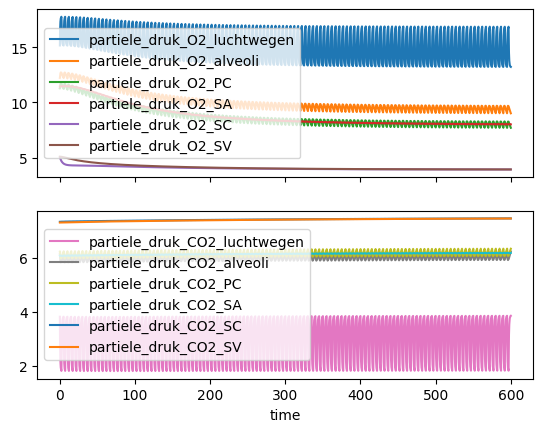

In [15]:
result[
    list(itertools.chain(*columns_partial_pressures))
].plot(subplots=columns_partial_pressures)


<Axes: xlabel='time'>

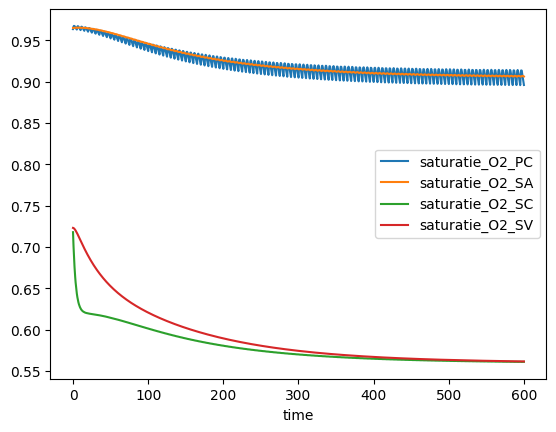

In [16]:
result[
    [
        "saturatie_O2_PC",
        "saturatie_O2_SA",
        "saturatie_O2_SC",
        "saturatie_O2_SV",
    ]
].plot()
